## Bank Customer Churn Analysis & Model Implementation

In [148]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_recall_curve, average_precision_score

In [149]:
df = pd.read_csv(r"Bank Customer Churn Prediction.csv")

In [150]:
df_copy = df.copy()

In [151]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [153]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [154]:
df.isna().sum().sum()

np.int64(0)

## Statistical Analysis with Visualization

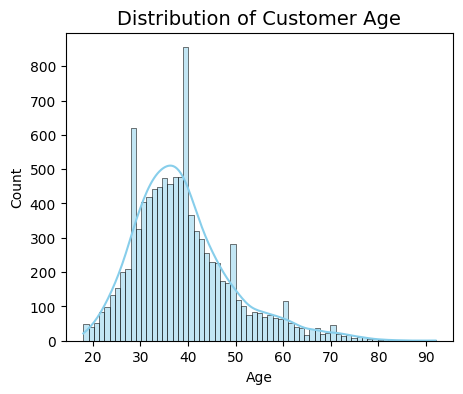

In [155]:
#Age Distribution
plt.figure(figsize=(5,4))
sns.histplot(data=df, x='age', kde=True, color='skyblue')
plt.title("Distribution of Customer Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### From dristibution of customer age's, majority age's are between 32 to 44. Age data is right skwed. Some of the data is abouve 70. Also there is some data around 90.

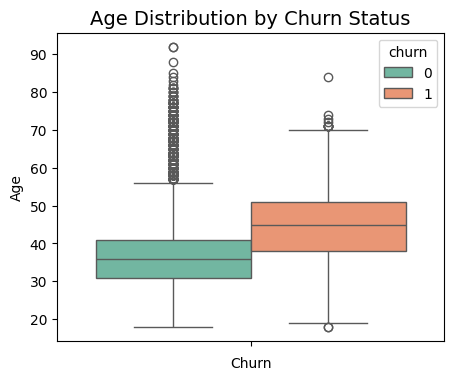

In [156]:
#Boxplot to Check outliers 

plt.figure(figsize=(5,4))
sns.boxplot(data=df, hue='churn', y='age', palette='Set2')
plt.title("Age Distribution by Churn Status", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Age")
# plt.legend(False)
plt.show()

### In this boxplot we can see there is a lot of suspicious outliers. Age may effect the churn in this bank.

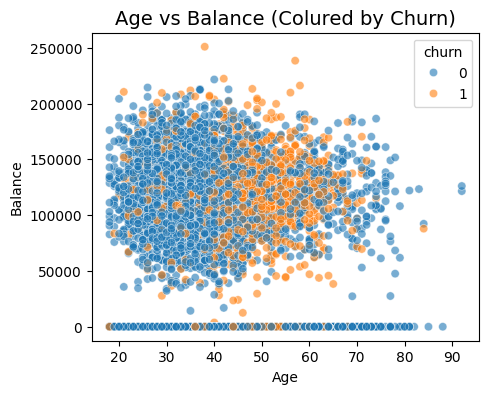

In [157]:
#Scatter plot for Age vs Churn rate

plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x='age', y='balance', hue='churn', alpha=0.6)
plt.title("Age vs Balance (Colured by Churn)", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Balance")
plt.show()

### It seems majority of older people no matter how much left in balance has churned

In [158]:
df['country'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [159]:
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [160]:
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

In [161]:
df.head(5)

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [162]:
corr_ = df[['credit_score','age','tenure','balance','products_number','credit_card','active_member','estimated_salary','churn','country_Germany','country_Spain','gender_Male']]
corr_matrix = corr_.corr()

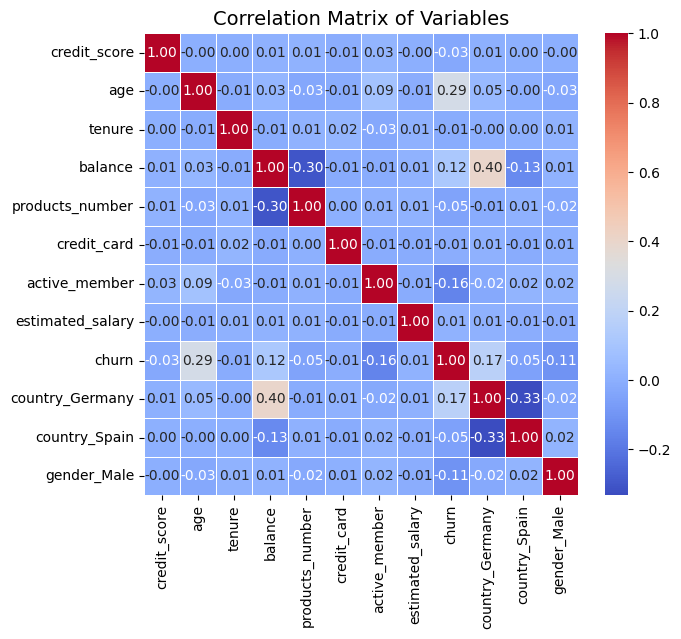

In [163]:
plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Variables", fontsize=14)
plt.show()

## Correlation Heatmap Analysis
### Correlation Heatmap shows us that most of the features in a negative correlation with Churn. Only Age, Balance and People from Germany positively associated with churn.

In [164]:
scaler = StandardScaler()

In [165]:
X = df.drop(columns=['customer_id','churn'])
y = df['churn']

In [166]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_temp, X_test, y_temp, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

### fit_transform on train data points then transform it to the test and validation set. We use fit_transform on training data and transform on test and validation data because we want the same scaling range on test and validation set.

In [167]:
X_train_scaled = scaler.fit_transform(X_train)
X_temp_scaled = scaler.transform(X_temp)
X_test_scaled = scaler.transform(X_test)

In [168]:
model = LogisticRegression(
    # l1_ratio=0,
    C=1,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)

In [169]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

In [170]:
#prediction on validation data
y_temp_pred = model.predict(X_temp_scaled)

#prediction on test data
y_test_pred = model.predict(X_test_scaled)

In [171]:
# Evaluation Score on Validation set & test set
print(f"Validation classification Report: {classification_report(y_temp, y_temp_pred)}")
print(f"Test classification Report: {classification_report(y_test, y_test_pred)}")

Validation classification Report:               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1194
           1       0.40      0.74      0.52       306

    accuracy                           0.72      1500
   macro avg       0.66      0.73      0.66      1500
weighted avg       0.81      0.72      0.74      1500

Test classification Report:               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1195
           1       0.40      0.72      0.51       305

    accuracy                           0.72      1500
   macro avg       0.65      0.72      0.66      1500
weighted avg       0.80      0.72      0.74      1500



## Confusion Matrix Visualization

In [172]:
cm = confusion_matrix(y_test, y_test_pred)

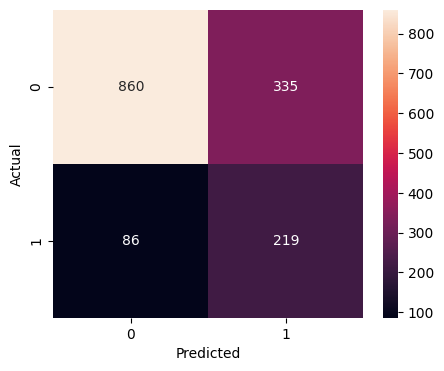

In [173]:
plt.figure(figsize=(5,4))
sns.heatmap(data=cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Confusion Matrix Heatmap Interpretation

### On top left actual not churn-->860 customers and model predict them well. Top right is actual not churn-->335 but model predict them as churned(False Positive).
### On bottom left actual churned customers-->86 but model fails to catch them(False negative). Bottom right is actual churned customers and model catch them all.

### So if we analyse, we clearly see model can't catch 81 churned customers which is not good for business insight. Business insight is to catch all the churned customers, it is quite acceptable if model predicts some not churn customers as churn.

## ROC Curve

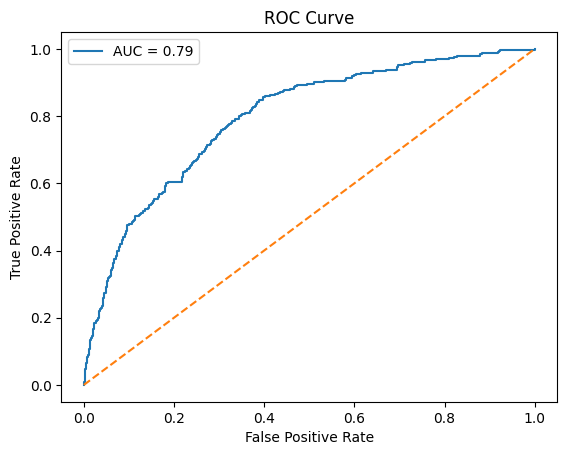

In [174]:
# y_prob = model.predict(X_test_scaled)[:,1] --> it represent actually final label(0/1) but for ROC curve we need probability score
y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, threshold = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend()
plt.show()


## ROC-AUC Curve Analysis

### ROC Curve shows the tradeoff between True Positive Rate and False Positive Rate across different classification thresholds. The curve staying far above the diagonal line indicates the model has good discriminative ability.

In [175]:
# calculate best threshold from ROC-AUC curve
j_scores = tpr - fpr

best_idx = np.argmax(j_scores)
best_threshold = threshold[best_idx]

In [176]:
print(best_threshold)

0.4246731235692


### So we found the best threshold with ROC-AUC. Lets implement it into our baseline model and analyse the performance.

In [177]:
y_pred_custom = (y_prob>=best_threshold).astype(int)
print(f"Custom threshold Confusion Matrix: {confusion_matrix(y_test, y_pred_custom)}")

Custom threshold Confusion Matrix: [[731 464]
 [ 46 259]]


In [178]:
print(f"Custom threshold Classification Report: {classification_report(y_test, y_pred_custom)}")

Custom threshold Classification Report:               precision    recall  f1-score   support

           0       0.94      0.61      0.74      1195
           1       0.36      0.85      0.50       305

    accuracy                           0.66      1500
   macro avg       0.65      0.73      0.62      1500
weighted avg       0.82      0.66      0.69      1500



## Custom Threshold Analysis

### From the custom threshold tuning Recall decreased. It may increase precision but model can't predict all the churned customers. Which is costly for business.

In [179]:
# lets check all the possible threshold and analyse the classification report
thresholds = [0.1,0.2,0.3,0.4,0.5,0.6]

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.94      0.01      0.03      1195
           1       0.21      1.00      0.34       305

    accuracy                           0.21      1500
   macro avg       0.57      0.51      0.18      1500
weighted avg       0.79      0.21      0.09      1500


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.97      0.18      0.30      1195
           1       0.23      0.98      0.38       305

    accuracy                           0.34      1500
   macro avg       0.60      0.58      0.34      1500
weighted avg       0.82      0.34      0.31      1500


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.37      0.53      1195
           1       0.27      0.93      0.42       305

    accuracy                           0.48      1500
   macro avg       0.61      0.65      0.48      1500
weighted avg       0.81   

## Theshold Analysis

### From all the threshold we can find the best threshold is 0.30, where churn recall is 0.93 and not churn recall is 0.37. But model evaluation about not churn is too poor, which also increase offer cost to the customers.

## Now lets implement PR Curve & Analyse the model

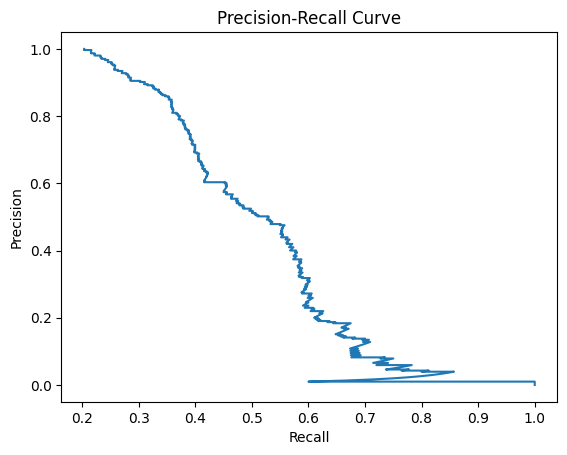

In [180]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_prob
)
plt.plot(precision, recall)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## PR-Curve Analysis
### Moderate Recall a useful but precision collapse in extreme recall.

In [181]:
pr_auc = average_precision_score(y_test, y_prob)
print(pr_auc)

0.5070284917981599


In [182]:
# F1 Optimization

thresholds = np.arange(0.1, 0.9, 0.01)

best_f1 = 0
best_threshold = 0
for t in thresholds:
    y_pred = (y_prob>=t).astype(int)
    # score = f1_score(y_test, y_prob) here y_prob is continuous targets so this line will give "binary and continuous target" error
    score = f1_score(y_test, y_pred) 

    if score>best_f1:
        best_f1 = score
        best_threshold = t

print(f"Best F1 Score: {best_f1}")
print(f"Best Threshold: {best_threshold}")


Best F1 Score: 0.5132496513249651
Best Threshold: 0.5699999999999997


In [183]:
# Cross Validation Status with Startified K Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1'
)

print(f"Score : {scores}")
print(f"Average Score: {scores.mean()}")


Score : [0.4868256  0.48402948 0.49204406 0.45742092 0.48831169]
Average Score: 0.4817263513095632


In [184]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [185]:
params = [
    {
        "solver":["lbfgs"],
        "penalty":["l2"],
        "C":[0.001,0.01,0.1,1,10]
    },

    {
        "solver":["liblinear"],
        "penalty":["l1","l2"],
        "C":[0.001,0.01,0.1,1,10]
    }
]

grid = GridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),
    param_grid=params,
    cv=cv,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

In [186]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


d:\Projects\house_price\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.001, 0.01, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}, {'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [187]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
0.483720281755127


In [188]:
best_model = grid.best_estimator_

In [189]:
y_prob_test = best_model.predict_proba(X_test_scaled)[:,1]

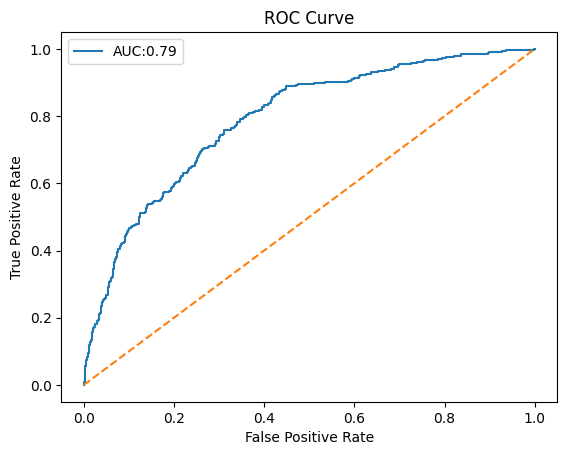

In [190]:
fpr, tpr, threshold = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC:{roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [191]:
#best threshold
j_scores = tpr-fpr
best_idx = np.argmax(j_scores)
best_threshold = threshold[best_idx]

print(best_threshold)

0.4887182862100214


In [192]:
y_pred_custom = (y_prob_test>best_threshold).astype(int)
print(f"Confuion Matrix: {confusion_matrix(y_test, y_pred_custom)}")
print(f"classification Report: {classification_report(y_test, y_pred_custom)}")

Confuion Matrix: [[823 372]
 [ 75 230]]
classification Report:               precision    recall  f1-score   support

           0       0.92      0.69      0.79      1195
           1       0.38      0.75      0.51       305

    accuracy                           0.70      1500
   macro avg       0.65      0.72      0.65      1500
weighted avg       0.81      0.70      0.73      1500



In [193]:
pr_auc = average_precision_score(y_test, y_prob_test)
print(f"PR AUC: {pr_auc}")

PR AUC: 0.5019410269738984


In [194]:
#Threshold Tuning

thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7]

best_f1 = 0
best_threshold = 0
for t in thresholds:
    y_pred = (y_prob_test>=t).astype(int)
    score = f1_score(y_test, y_pred)

    if score>best_f1:
        best_f1 = score
        best_threshold = t

print(f"Best F1 Score: {best_f1}")
print(f"Best Threshold: {best_threshold}")

Best F1 Score: 0.5087924970691676
Best Threshold: 0.5


### After tuning the model we can notice that model perfomance has been decreased. Lets take a look into PR Curve.

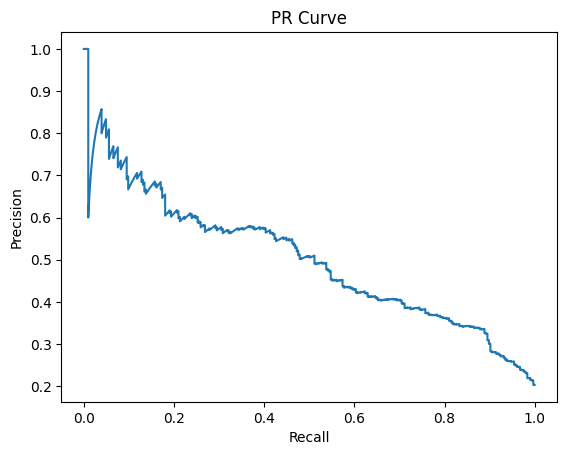

In [195]:
#Precision Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_test)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title('PR Curve')
plt.show()

In [196]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

## Feature Importance Interpretation
### From the feature importance table we can assume that some features are negatively correlated and others are positively corelated with target variable.
### Among them "Age", "Balance" and "Country Germany" quite strongly correlated with target varibale.

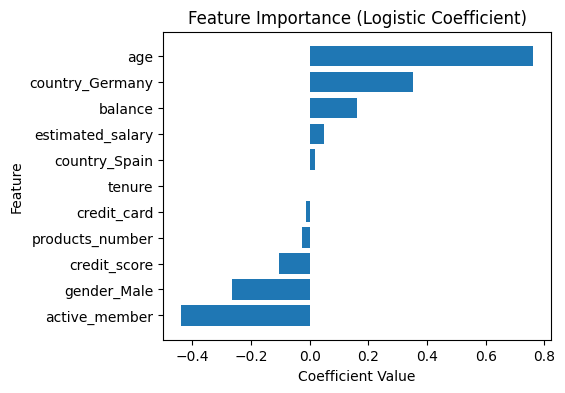

In [197]:
coef_df = coef_df.sort_values(by="Coefficient")

plt.figure(figsize=(5,4))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title("Feature Importance (Logistic Coefficient)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [198]:
from sklearn.calibration import calibration_curve

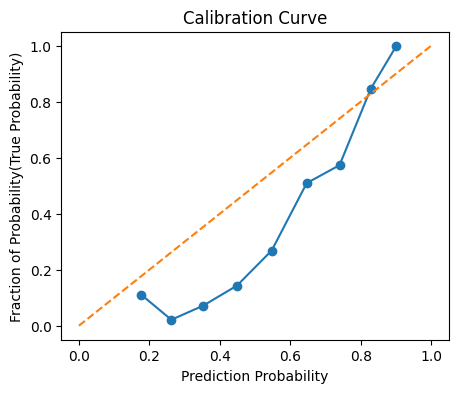

In [199]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_test,
    n_bins=10
)

plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],"--")
plt.xlabel("Prediction Probability")
plt.ylabel("Fraction of Probability(True Probability)")
plt.title("Calibration Curve")
plt.show()

In [200]:
from sklearn.tree import DecisionTreeClassifier

In [201]:
tree_model = DecisionTreeClassifier(
    criterion='gini', max_depth=5, random_state=42, class_weight='balanced'
)

In [202]:
tree_model.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [203]:
tree_val_pred = tree_model.predict(X_temp_scaled)
tree_test_pred = tree_model.predict(X_test_scaled)

In [204]:
print(f"Classification Matrix(Val set): {classification_report(y_temp, tree_val_pred)}")
print(f"Classification Matrix(Test set): {classification_report(y_test, tree_test_pred)}")

Classification Matrix(Val set):               precision    recall  f1-score   support

           0       0.94      0.77      0.85      1194
           1       0.47      0.79      0.59       306

    accuracy                           0.78      1500
   macro avg       0.70      0.78      0.72      1500
weighted avg       0.84      0.78      0.79      1500

Classification Matrix(Test set):               precision    recall  f1-score   support

           0       0.93      0.78      0.85      1195
           1       0.47      0.75      0.58       305

    accuracy                           0.78      1500
   macro avg       0.70      0.77      0.71      1500
weighted avg       0.83      0.78      0.79      1500



## Baseline Decision Tree Analysis

### Performance about Decision Tree is good. Where recall is 75% in test dataset, but precision is weak only 47%. It means models gives 53% false alarm. Which is also quite costly.

In [205]:
df.shape

(10000, 13)

In [206]:
params = {
    "criterion":['gini', 'entropy'],
    "max_depth":[3,5,6,7,10,15, None],
    "min_samples_split":[10,15,20,30], 
    "min_samples_leaf":[4,6,8,10]
}

In [207]:
grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid=params,
    cv=cv,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

In [208]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 224 candidates, totalling 1120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [4, 6, ...], 'min_samples_split': [10, 15, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [209]:
print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 20}
0.5661862349080129


In [210]:
best_tree = grid.best_estimator_

In [211]:
best_tree.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [212]:
y_val_tree = best_tree.predict(X_temp_scaled)
y_test_tree = best_tree.predict(X_test_scaled)

In [213]:
print(f"Validation Classification Report: {classification_report(y_temp, y_val_tree)}")
print(f"Test Classification Report: {classification_report(y_test, y_test_tree)}")

Validation Classification Report:               precision    recall  f1-score   support

           0       0.94      0.75      0.84      1194
           1       0.46      0.82      0.59       306

    accuracy                           0.77      1500
   macro avg       0.70      0.79      0.72      1500
weighted avg       0.85      0.77      0.79      1500

Test Classification Report:               precision    recall  f1-score   support

           0       0.93      0.74      0.83      1195
           1       0.44      0.79      0.57       305

    accuracy                           0.75      1500
   macro avg       0.69      0.77      0.70      1500
weighted avg       0.83      0.75      0.78      1500



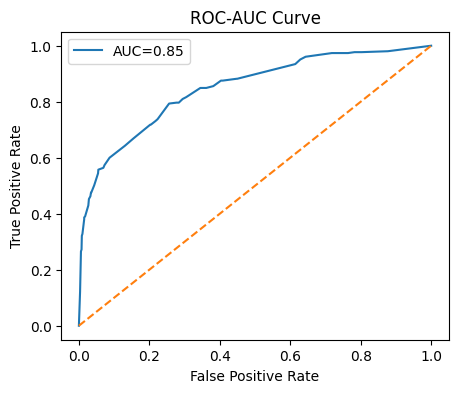

In [214]:
#decision tree roc auc curve
tree_prob = best_tree.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, tree_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

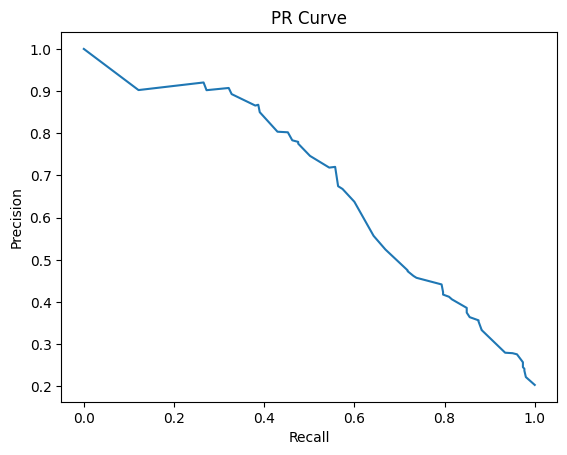

In [215]:
precision, recall, thresholds = precision_recall_curve(y_test, tree_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.show()

### Okay we used "class_weight = balanced" in our Decesion tree algorithm. Lets see imbalance handling actually helps or not. 

In [216]:
grid_2 = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        class_weight=None
    ),
    param_grid=params,
    cv=cv,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

In [217]:
grid_2.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 224 candidates, totalling 1120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [4, 6, ...], 'min_samples_split': [10, 15, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [218]:
print(grid_2.best_params_)
print(grid_2.best_score_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 30}
0.5643836440118608


In [219]:
best_tree_2 = grid_2.best_estimator_

In [220]:
y_val_tree2 = best_tree_2.predict(X_temp_scaled)
y_test_tree2 = best_tree_2.predict(X_test_scaled)

In [221]:
print(f"Validation Classification Report: {classification_report(y_temp, y_val_tree2)}")
print(f"Test Classification Report: {classification_report(y_test, y_test_tree2)}")

Validation Classification Report:               precision    recall  f1-score   support

           0       0.87      0.94      0.91      1194
           1       0.67      0.46      0.54       306

    accuracy                           0.84      1500
   macro avg       0.77      0.70      0.72      1500
weighted avg       0.83      0.84      0.83      1500

Test Classification Report:               precision    recall  f1-score   support

           0       0.88      0.94      0.91      1195
           1       0.68      0.48      0.56       305

    accuracy                           0.85      1500
   macro avg       0.78      0.71      0.74      1500
weighted avg       0.84      0.85      0.84      1500



## Decision Tree Analysis
### So we can notice that without imbalance handling model is poor about to catch the churned customer. In our validation set recall is 0.46 and precision over recall is good which is 0.67. Also in test set recall is 0.48 and precision over recall is 0.68. This is not satisfying, we need a balance result between precision and recall.

In [222]:
from sklearn.ensemble import RandomForestClassifier

In [223]:
rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,7,8,9],
    "min_samples_split":[5,10,20],
    "min_samples_leaf":[5,8,10,15],
    "max_features":['sqrt', 'log2']
}

In [224]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42,class_weight="balanced_subsample"),
    param_grid=rf_params,
    cv=cv,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

In [225]:
rf_grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [5, 8, ...], 'min_samples_split': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

In [226]:
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 200}
0.6168842829111425


In [227]:
best_rf_model = rf_grid.best_estimator_

In [228]:
y_val_rf = best_rf_model.predict(X_temp_scaled)
y_test_rf = best_rf_model.predict(X_test_scaled)

In [229]:
print(f"Classification report(validation set): {classification_report(y_temp, y_val_rf)}")
print(f"Classification report(test set): {classification_report(y_test, y_test_rf)}")

Classification report(validation set):               precision    recall  f1-score   support

           0       0.93      0.87      0.89      1194
           1       0.58      0.73      0.65       306

    accuracy                           0.84      1500
   macro avg       0.75      0.80      0.77      1500
weighted avg       0.86      0.84      0.84      1500

Classification report(test set):               precision    recall  f1-score   support

           0       0.92      0.86      0.89      1195
           1       0.57      0.72      0.64       305

    accuracy                           0.83      1500
   macro avg       0.75      0.79      0.76      1500
weighted avg       0.85      0.83      0.84      1500



## Random Forest Analysis
### Now if we analyse the classification report of best rf model, we can see signaficantly improved our recall(0.73 on validation set and 0.72 in test set) and also improve our precision(0.58 in validation set and 0.57 in test set). But we want more balance between precision and recall. Lets try SMOTE on Random Forest.

## ROC-AUC & PR-CURVE Analysis

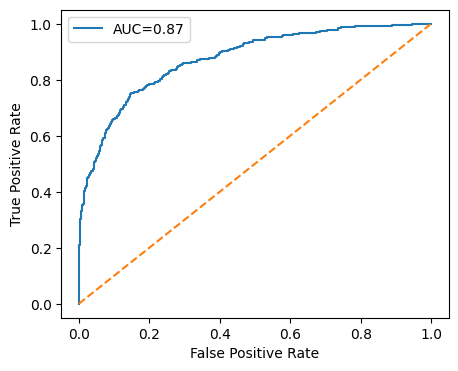

In [230]:
#ROC AUC Curve
random_forest_prob = best_rf_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, threshold = roc_curve(y_test, random_forest_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Best Threshold:0.5725 (F1_Score:0.6494)


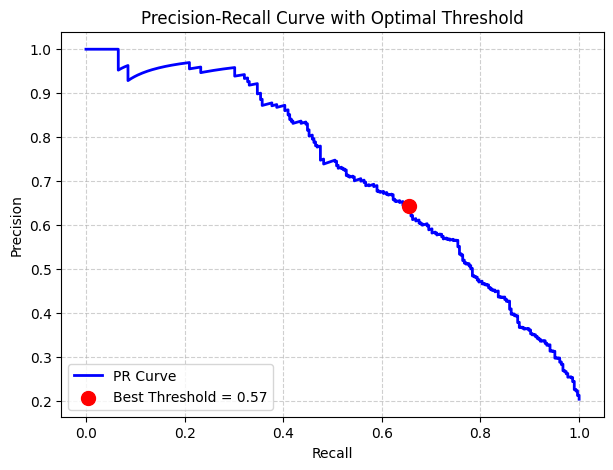

In [231]:
#PR Curve
precision, recall, thresholds = precision_recall_curve(y_test, random_forest_prob)
f1_scores = (2*precision[:-1] * recall[:-1])/(precision[:-1] + recall[:-1] + 1e-10) #to avoid division by zero error we add a minimal number 1e-10

#locate the index of the highest f1_score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print(f"Best Threshold:{best_threshold:.4f} (F1_Score:{f1_scores[best_idx]:.4f})")
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label='PR Curve', color='blue', lw=2)
plt.scatter(best_recall, best_precision, color='red', marker='o', s=100, label=f"Best Threshold = {best_threshold:.2f}", zorder=5)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Optimal Threshold")
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Analysis of ROC-AUC Curve and PR Curve

### So if we analyse the ROC-AUC curve we clearly see AUC = 0.87 means that if we randomly select one churned customer and one non-churned customer, the model has an 87% chance of assigning a higher risk score to the churned customer.


### Thats where pr curve comes and play the game. It tels us the precision over recall. And also we calculate the harmonic mean which is F1_score. And with F1_score we found the best threshold that gives us the optimal performance.

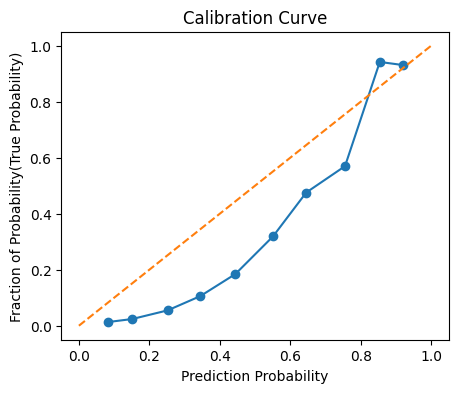

In [232]:
#Calibration Curve of Random Forest Model
actual_prob, pred_prob = calibration_curve(
    y_test,
    random_forest_prob,
    n_bins=10
)
plt.figure(figsize=(5,4))
plt.plot(pred_prob, actual_prob, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Prediction Probability")
plt.ylabel("Fraction of Probability(True Probability)")
plt.title("Calibration Curve")
plt.show()

## Calibration Curve Analysis
### The calibration curve lies below the diagonal line. Therefore, the Random Forest model tends to overestimate churn probabilities. Predicted probabilities are more extreme than the actual observed churn rates.

## Feature Importance

In [233]:
feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(5))

           Feature  Importance
1              age    0.357697
4  products_number    0.246485
3          balance    0.104289
8  country_Germany    0.065996
6    active_member    0.062558


In [234]:
from imblearn.over_sampling import SMOTE

In [235]:
smote = SMOTE()

In [236]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [237]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

churn
0    5574
1    1426
Name: count, dtype: int64
churn
0    5574
1    5574
Name: count, dtype: int64


In [238]:
rf_grid.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [5, 8, ...], 'min_samples_split': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

In [239]:
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}
0.8353452666363316


In [240]:
best_model_rfsmote = rf_grid.best_estimator_

In [241]:
y_val_rfsmote = best_model_rfsmote.predict(X_temp_scaled)
y_test_rfsmote = best_model_rfsmote.predict(X_test_scaled)

In [242]:
print(f"Classification report(validation set): {classification_report(y_temp, y_val_rfsmote)}")
print(f"Classification report(test set): {classification_report(y_test, y_test_rfsmote)}")

Classification report(validation set):               precision    recall  f1-score   support

           0       0.92      0.86      0.89      1194
           1       0.58      0.73      0.64       306

    accuracy                           0.83      1500
   macro avg       0.75      0.79      0.77      1500
weighted avg       0.85      0.83      0.84      1500

Classification report(test set):               precision    recall  f1-score   support

           0       0.92      0.85      0.89      1195
           1       0.56      0.73      0.63       305

    accuracy                           0.83      1500
   macro avg       0.74      0.79      0.76      1500
weighted avg       0.85      0.83      0.83      1500



## Random Forest in SMOTE dataset Analysis
### After SMOTE there is no improvement on our classification report , Reduced performance instead of increasing it. Precision dropped at 0.56 in validation set and 0.54 in test set.

### Due to unsatisfactory performance calibration curve implemention is unnecessary.

In [243]:
from xgboost import XGBClassifier

In [244]:
#negative & positive class estimated ratio for parameter
num_neg = np.sum(y_train==0)
num_pos = np.sum(y_train==1)
estimated_ratio = num_neg/num_pos

In [245]:
xgb_params = {
    "max_depth":[5,6,7,8],
    "learning_rate":[0.01, 0.1, 0.3, 0.5, 1],
    "n_estimators":[100,200,300],
    "subsample":[0.5, 0.8, 1]
}

In [246]:
xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        scale_pos_weight=estimated_ratio,
        eval_metric = "logloss"
    ),
    param_grid=xgb_params,
    cv=cv,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

In [247]:
xgb_grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [5, 6, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.5, 0.8, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [248]:
xgb_grid_model = xgb_grid.best_estimator_

In [249]:
y_temp_xgb_g = xgb_grid_model.predict(X_temp_scaled)
y_test_xgb_g = xgb_grid_model.predict(X_test_scaled)

In [250]:
print(f"Classification report validation:\n{classification_report(y_temp, y_temp_xgb_g)}")
print(f"Classification report of test:\n{classification_report(y_test, y_test_xgb_g)}")

Classification report validation:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1194
           1       0.60      0.70      0.65       306

    accuracy                           0.84      1500
   macro avg       0.76      0.79      0.77      1500
weighted avg       0.85      0.84      0.85      1500

Classification report of test:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1195
           1       0.57      0.70      0.63       305

    accuracy                           0.83      1500
   macro avg       0.74      0.78      0.76      1500
weighted avg       0.85      0.83      0.84      1500



In [251]:
xgb_random = RandomizedSearchCV(
    XGBClassifier(
        random_state = 42,
        scale_pos_weight=estimated_ratio,
        eval_metric = "logloss"
    ),
    param_distributions=xgb_params,
    cv=cv,
    scoring='f1',
    verbose=3,
    n_jobs=-1
)

In [252]:
xgb_random.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [5, 6, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.5, 0.8, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [253]:
best_xgb = xgb_random.best_estimator_

In [254]:
y_temp_xgb = best_xgb.predict(X_temp_scaled)
y_test_xgb = best_xgb.predict(X_test_scaled)

In [255]:
print(f"Classification report validation:\n{classification_report(y_temp, y_temp_xgb)}")
print(f"Classification report of test:\n{classification_report(y_test, y_test_xgb)}")

Classification report validation:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1194
           1       0.60      0.70      0.65       306

    accuracy                           0.84      1500
   macro avg       0.76      0.79      0.77      1500
weighted avg       0.85      0.84      0.85      1500

Classification report of test:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1195
           1       0.57      0.70      0.63       305

    accuracy                           0.83      1500
   macro avg       0.74      0.78      0.76      1500
weighted avg       0.85      0.83      0.84      1500



## PR Curve & PR AUC comparison between Random Forest & XGBoost

### Note: We use Random Forest model without SMOTE , because it is the model that gives best shoot till now

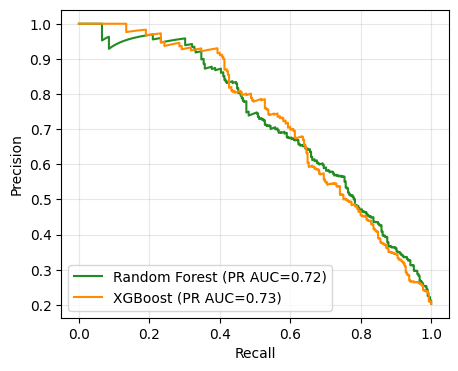

In [256]:
#probability score
rf_prob = best_rf_model.predict_proba(X_test_scaled)[:,1]
xgb_prob = xgb_grid_model.predict_proba(X_test_scaled)[:,1]

#genarate data for pr curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_prob)
precision_xgb, recall_xgb, _ =precision_recall_curve(y_test, xgb_prob)

#PR AUC/Average Precision calculation
pr_auc_rf = average_precision_score(y_test, rf_prob)
pr_auc_xgb = average_precision_score(y_test, xgb_prob)

#graph
plt.figure(figsize=(5,4))
plt.plot(recall_rf, precision_rf, label=f"Random Forest (PR AUC={pr_auc_rf:.2f})", color="forestgreen")
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (PR AUC={pr_auc_xgb:.2f})", color="darkorange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [257]:
prob_true_rf, prob_pred_rf = calibration_curve(y_test, rf_prob, n_bins=10)

## XGBoost Model Analysis
### After Xgboost with GridSearch CV and Random Search CV there is no difference in performance with Random Forest SMOTE Model. But at this stage we can consider Xgboost model, because it uses mathematical ratio between negative and positive class not synthetic data.

## What can we do now?
### The answer is feature engineering. And then we will try again with XGBoost


## Feature Engineering
### Main key of Feature Engineering is the domain knowledge. Let's research some knowledge about banking sectior and apply it to create some feature to train the model.

In [258]:
def banking_feature_eng(dataset):
    df_fe = dataset.copy()

    #interaction feature
    df_fe['balance_salary_ratio'] = df_fe['balance']/(df_fe['estimated_salary']+1)
    df_fe['tenure_age_ratio'] = df_fe['tenure']/(df_fe['age']+1)
    df_fe['credit_per_tenure'] = df_fe['credit_score']/(df_fe['tenure']+1)

    #binary feature
    mean_balance = df_fe['balance'].mean()
    df_fe['is_welthy_active'] = ((df_fe['balance'] > mean_balance) & (df_fe['active_member'] == 1)).astype(int)

    #create bin based on age
    age_bins = [18, 30, 50, 100]
    age_labels = ['Young', 'Middle_Aged', 'Senior']
    df_fe['age_group'] = pd.cut(df_fe['age'], bins=age_bins, labels=age_labels, include_lowest=True)

    #one hot for age_group
    df_fe = pd.get_dummies(df_fe, columns=['age_group'], drop_first=True)

    # capping age outlier with 99 percentile method
    upper_limit = df_fe['age'].quantile(0.99)
    df_fe['age'] = np.where(df_fe['age']>upper_limit, upper_limit, df_fe['age'])

    return df_fe

In [259]:
engineered_df = banking_feature_eng(df)

In [260]:
X = engineered_df.drop(columns=['customer_id', 'churn'])
y = engineered_df['churn']

In [261]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_temp, X_test, y_temp, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [262]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

skf_accrcy_list = []
skf_f1_list = []
skf_pr_auc_list = []

In [263]:
# convert training data into numpy array
X_train_arr = np.array(X_train)
y_train_arr = np.array(y_train)


#scale pos weight
neg_num = np.sum(y_train == 0)
pos_num = np.sum(y_train == 1)
estimated_ratio = neg_num/pos_num

In [264]:
from xgboost import XGBClassifier

In [265]:
model_skf = XGBClassifier(
    max_depth = 5,
    scale_pos_weight = estimated_ratio,
    eval_metric = 'logloss',
    learning_rate = 0.1,
    n_estimators = 100
)

In [266]:
from sklearn.metrics import accuracy_score, f1_score, average_precision_score

In [267]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_arr, y_train_arr), 1):
    #split data with for specific index
    X_tr, X_va = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_va = y_train_arr[train_idx], y_train_arr[val_idx]

    model_skf.fit(X_tr, y_tr)

    y_pred = model_skf.predict(X_va)
    y_prob = model_skf.predict_proba(X_va)[:,1]

    #calculate the evaluation metrics
    acc = accuracy_score(y_va, y_pred)
    f1 = f1_score(y_va, y_pred)
    pr_auc = average_precision_score(y_va,y_prob)

    skf_accrcy_list.append(acc)
    skf_f1_list.append(f1)
    skf_pr_auc_list.append(pr_auc)

    print(f"Fold {fold} -> Accuracy: {acc:.4f} | F1_score: {f1:.4f} | PR_AUC: {pr_auc:.4f}")

Fold 1 -> Accuracy: 0.7957 | F1_score: 0.5627 | PR_AUC: 0.6594
Fold 2 -> Accuracy: 0.7971 | F1_score: 0.5943 | PR_AUC: 0.6914
Fold 3 -> Accuracy: 0.8186 | F1_score: 0.6019 | PR_AUC: 0.6974
Fold 4 -> Accuracy: 0.8114 | F1_score: 0.6163 | PR_AUC: 0.7059
Fold 5 -> Accuracy: 0.7743 | F1_score: 0.5407 | PR_AUC: 0.6066
Fold 6 -> Accuracy: 0.8114 | F1_score: 0.6271 | PR_AUC: 0.6595
Fold 7 -> Accuracy: 0.8086 | F1_score: 0.5864 | PR_AUC: 0.6848
Fold 8 -> Accuracy: 0.8043 | F1_score: 0.5759 | PR_AUC: 0.6887
Fold 9 -> Accuracy: 0.8086 | F1_score: 0.5939 | PR_AUC: 0.6402
Fold 10 -> Accuracy: 0.8286 | F1_score: 0.6450 | PR_AUC: 0.7505


In [268]:
print(f"Average SKF Accuracy: {np.mean(skf_accrcy_list):.4f}")
print(f"Average SKF F1_Score: {np.mean(skf_f1_list):.4f}")
print(f"Average SKF PR AUC: {np.mean(skf_pr_auc_list):.4f}")

Average SKF Accuracy: 0.8059
Average SKF F1_Score: 0.5944
Average SKF PR AUC: 0.6784


In [269]:
model_skf.fit(X_train, y_train)

y_prob_test = model_skf.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.01)
best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_prob_test>=t).astype(int)
    score = f1_score(y_test, y_pred_t)

    if score>best_f1:
        best_f1 = score
        best_t = t


print(f"Optimal Threshold for Test set: {best_t:.2f}")
print(f"Optimal F1_Score on Test set:{best_f1:.4f}")

Optimal Threshold for Test set: 0.68
Optimal F1_Score on Test set:0.6597


In [270]:
#look into classification report with optimal threshold
y_pred_final = (y_prob_test >= best_t).astype(int)
print("\nFinal Test Classification Report (After Feature Engineering & Tuning):")
print(classification_report(y_test, y_pred_final))


Final Test Classification Report (After Feature Engineering & Tuning):
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1195
           1       0.71      0.62      0.66       305

    accuracy                           0.87      1500
   macro avg       0.81      0.78      0.79      1500
weighted avg       0.87      0.87      0.87      1500



### Now let's tune the hyperparameter for XGBoost Classifier

In [271]:
df = banking_feature_eng(df)

X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

In [272]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [273]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_weight = neg / pos

model = XGBClassifier(
    max_depth=5,
    n_estimators=200,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_weight,
    random_state=42
)


In [274]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [275]:
val_prob = model.predict_proba(X_val)[:, 1]


#threshold tuning on validation set
thresholds = np.arange(0.1, 0.9, 0.01)

best_t = 0
best_f1 = 0

for t in thresholds:
    val_pred = (val_prob >= t).astype(int)
    score = f1_score(y_val, val_pred)

    if score > best_f1:
        best_f1 = score
        best_t = t

print("Best Threshold:", best_t)
print("Best Validation F1:", best_f1)


#final test evaluation
test_prob = model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_t).astype(int)

print("\n===== FINAL TEST RESULTS =====")
print(classification_report(y_test, test_pred))

Best Threshold: 0.6099999999999998
Best Validation F1: 0.6338983050847458

===== FINAL TEST RESULTS =====
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1195
           1       0.62      0.61      0.62       305

    accuracy                           0.85      1500
   macro avg       0.76      0.76      0.76      1500
weighted avg       0.85      0.85      0.85      1500



## Final Test Evaluation for best F1 Score

In [281]:
thresholds = [0.20,0.25,0.30,0.35,0.40,0.45,0.50]
y_prob = model.predict_proba(X_test)[:,1]
for t in thresholds:
    y_pred = (y_prob>=t).astype(int)
    
    print(f"\nThreshold:{t}")
    print(classification_report(y_test, y_pred))


Threshold:0.2
              precision    recall  f1-score   support

           0       0.96      0.60      0.74      1195
           1       0.37      0.90      0.52       305

    accuracy                           0.66      1500
   macro avg       0.66      0.75      0.63      1500
weighted avg       0.84      0.66      0.70      1500


Threshold:0.25
              precision    recall  f1-score   support

           0       0.95      0.67      0.78      1195
           1       0.39      0.85      0.54       305

    accuracy                           0.70      1500
   macro avg       0.67      0.76      0.66      1500
weighted avg       0.83      0.70      0.73      1500


Threshold:0.3
              precision    recall  f1-score   support

           0       0.94      0.72      0.82      1195
           1       0.43      0.83      0.57       305

    accuracy                           0.74      1500
   macro avg       0.69      0.77      0.69      1500
weighted avg       0.84     

### Although threshold 0.30 provides the highest churn recall (83%), it generates a large number of false positives, leading to higher customer retention campaign costs. Threshold 0.35 offers a better balance between precision and recall while still maintaining strong churn detection capability (79% recall). Therefore, 0.35 was selected as the operational threshold.

In [285]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

In [286]:
target_recall = 0.80
idx = np.where(recall >= target_recall)[0][-1]
best_threshold = thresholds[idx]
print(best_threshold)

0.33733398


In [287]:
test_pred = (test_prob>=best_threshold).astype(int)

In [288]:
print(f"Final Model Report")
print(classification_report(y_test, test_pred))

Final Model Report
              precision    recall  f1-score   support

           0       0.94      0.75      0.84      1195
           1       0.45      0.80      0.58       305

    accuracy                           0.76      1500
   macro avg       0.70      0.78      0.71      1500
weighted avg       0.84      0.76      0.78      1500

